In [5]:
import pyodbc
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
conn=pyodbc.connect('Driver={SQL Server};' 'Server=DESKTOP-JJVDSU3;'
                    'Database=BankingCase;' 'Trusted_connection=yes')
if conn:
    print('true')

query='''select * from [banking-clients]'''
df=pd.read_sql(query,conn)
df

true


C:\Users\DELL\AppData\Local\Temp\ipykernel_24524\2540817662.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


,Client_ID,Name,Age,Location_ID,Joined_Bank,Banking_Contact,Nationality,Occupation,Fee_Structure,Loyalty_Classification,...,Bank_Deposits,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,1.485829e+06,6.036179e+05,607332.437500,12249.959961,1.134475e+06,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,6.414828e+05,2.295214e+05,344635.156250,61162.308594,2.000526e+06,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,1.033402e+06,6.526747e+05,203054.343750,79071.781250,5.481376e+05,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1.048158e+06,1.048158e+06,234685.015625,57513.648438,1.148402e+06,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,4.877825e+05,4.466442e+05,128351.453125,30012.140625,1.674412e+06,0,3,1,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,IND66827,Earl Hall,82,8760,2014-10-09,Joshua Bennett,American,Accounting Assistant III,High,Gold,...,1.089957e+06,5.328679e+05,657849.625000,12947.309570,1.238860e+06,1,3,3,2,4
2996,IND40556,Billy Williamson,44,32837,2009-02-05,Dennis Ruiz,European,Paralegal,Mid,Gold,...,1.368913e+05,5.658174e+04,93195.609375,23205.689453,2.771711e+05,1,2,3,2,5
2997,IND72414,Victor Black,70,36088,2009-12-29,Joshua Ryan,American,Statistician IV,Low,Jade,...,2.148609e+05,1.587261e+05,35539.148438,30291.810547,5.029472e+05,2,2,3,2,6
2998,IND46652,Andrew Ford,56,24871,2006-02-13,Nicholas Cunningham,European,Human Resources Assistant III,Mid,Jade,...,7.426302e+05,4.046382e+05,56411.328125,6413.140137,1.538369e+06,3,1,3,2,7


In [6]:
# Check the shape of the DataFrame
print("Shape of the DataFrame:", df.shape)

# Get a concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()


Shape of the DataFrame: (3000, 25)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client_ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location_ID               3000 non-null   int64  
 4   Joined_Bank               3000 non-null   object 
 5   Banking_Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee_Structure             3000 non-null   object 
 9   Loyalty_Classification    3000 non-null   object 
 10  Estimated_Income          3000 non-null   float64
 11  Superannuation_Savings    3000 non-null   float64
 12  Amount_of_Credit_Cards    3000 non-null   int64  
 13  Credit_Card

In [7]:
df["Estimated_Income"]

0        75384.773438
1       289834.312500
2       169935.234375
3       356808.125000
4       130711.679688
            ...      
2995    297617.125000
2996     42397.460938
2997     48339.878906
2998    107265.867188
2999     56826.531250
Name: Estimated_Income, Length: 3000, dtype: float64

In [8]:
# Define income band boundaries
bins = [0, 100000, 300000, float('inf')]
labels = ['Low', 'Mid', 'High']

# Create the 'Income Band' column using pd.cut
df['Income_Band'] = pd.cut(df['Estimated_Income'], bins=bins, labels=labels, include_lowest=True)

In [9]:

# Examine the distribution of unique categories in categorical columns
categorical_cols = df[["BRId", "GenderId", "IAId", "Amount_of_Credit_Cards", "Nationality", "Occupation", "Fee_Structure", "Loyalty_Classification", "Properties_Owned", "Risk_Weighting", "Income_Band"]].columns
for col in categorical_cols:
  # if col in ["Client ID","Name","Joined Bank"]:
  #   continue
  print(f"\nValue Counts for '{col}':")
  display(df[col].value_counts())


Value Counts for 'BRId':


BRId
3    1352
1     660
2     495
4     493
Name: count, dtype: int64


Value Counts for 'GenderId':


GenderId
2    1512
1    1488
Name: count, dtype: int64


Value Counts for 'IAId':


...

Properties_Owned
2    777
1    776
3    742
0    705
Name: count, dtype: int64


Value Counts for 'Risk_Weighting':


Risk_Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64


Value Counts for 'Income_Band':


Income_Band
Mid     1517
Low     1027
High     456
Name: count, dtype: int64

# Generate descriptive statistics for numerical columns

In [10]:

print("\nDescriptive Statistics for Numerical Columns:")
display(df.describe())


Descriptive Statistics for Numerical Columns:


,Age,Location_ID,Estimated_Income,Superannuation_Savings,Amount_of_Credit_Cards,Credit_Card_Balance,Bank_Loans,Bank_Deposits,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034184,25531.599685,1.463667,3176.206944,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529998,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808180,16259.950768,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924033,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480469,1482.030029,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.597656,12513.774902,1.000000,1236.630005,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542236,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.476562,22357.355469,1.000000,2560.804932,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190430,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.300781,35464.741211,2.000000,4522.632690,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.391602,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.250000,75963.898438,3.000000,13991.990234,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.867188,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [11]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)


Missing values per column:
 Client_ID                   0
Name                        0
Age                         0
Location_ID                 0
Joined_Bank                 0
Banking_Contact             0
Nationality                 0
Occupation                  0
Fee_Structure               0
Loyalty_Classification      0
Estimated_Income            0
Superannuation_Savings      0
Amount_of_Credit_Cards      0
Credit_Card_Balance         0
Bank_Loans                  0
Bank_Deposits               0
Checking_Accounts           0
Saving_Accounts             0
Foreign_Currency_Account    0
Business_Lending            0
Properties_Owned            0
Risk_Weighting              0
BRId                        0
GenderId                    0
IAId                        0
Income_Band                 0
dtype: int64


In [14]:
df['Joined_Bank'] = pd.to_datetime(df['Joined_Bank'], format='%d-%m-%Y', errors='coerce')
print(df['Joined_Bank'].dtype)


datetime64[ns]


# Univariate Analysis

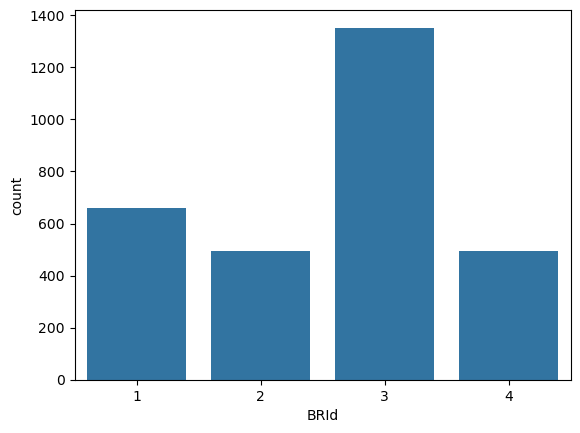

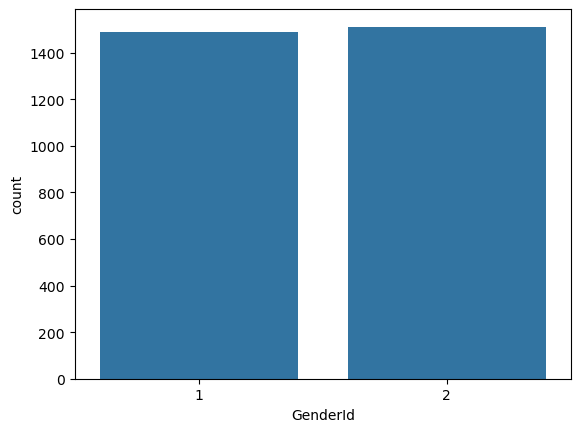

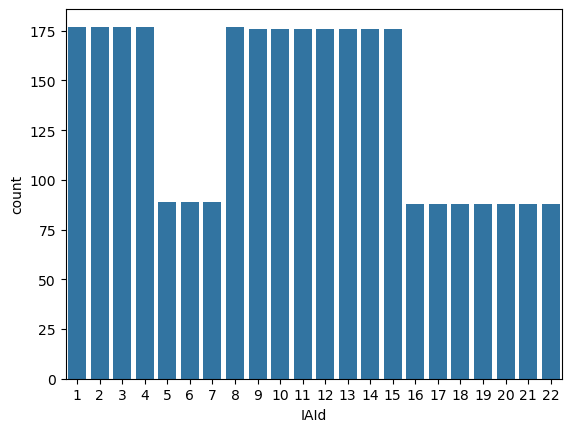

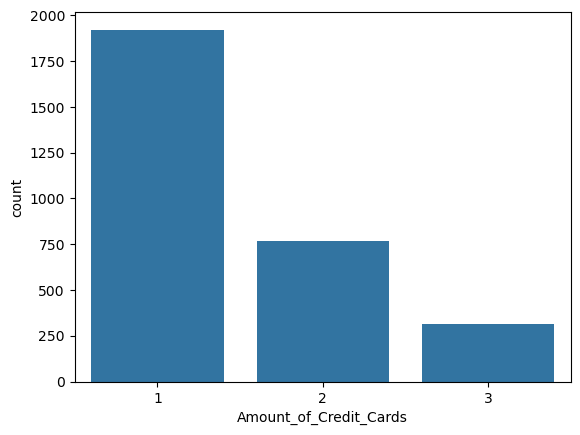

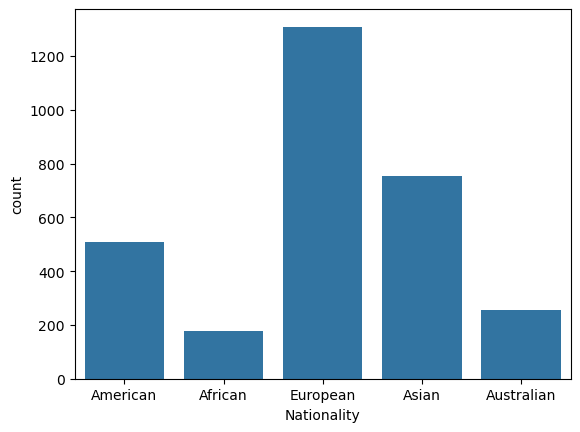

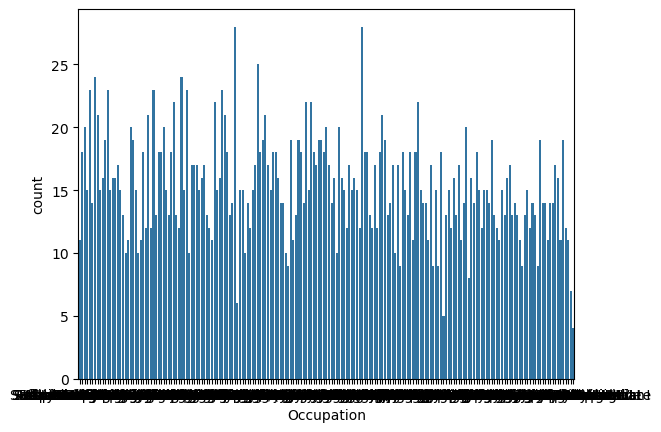

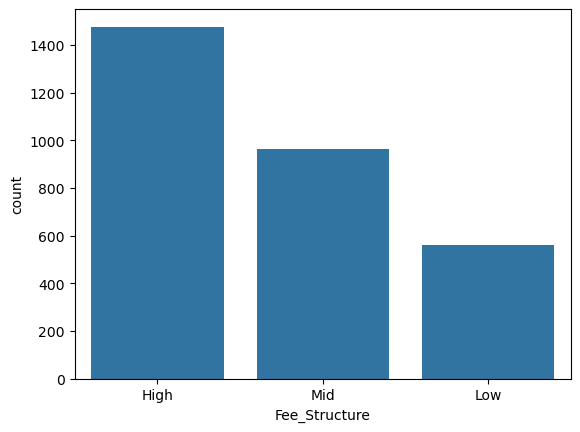

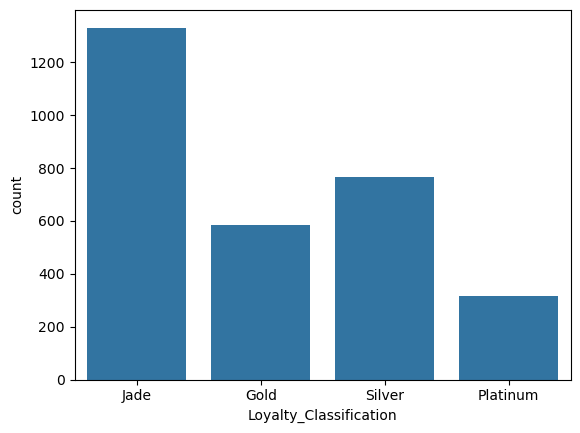

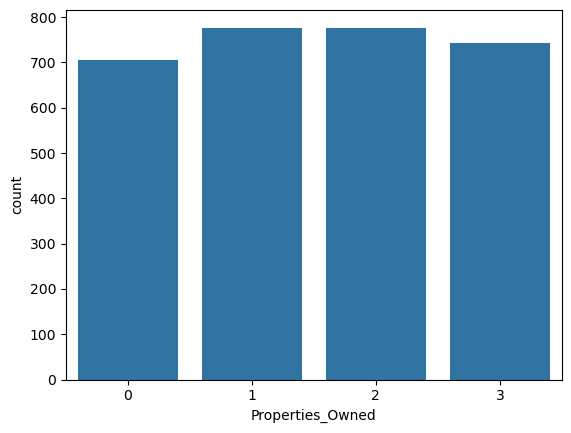

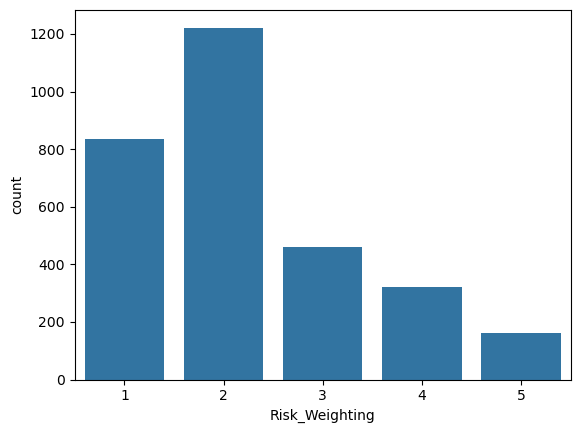

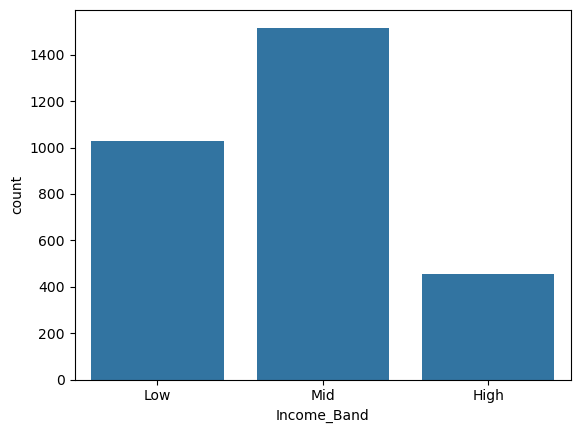

In [19]:
for i, predictor in enumerate(df[["BRId", "GenderId", "IAId", "Amount_of_Credit_Cards", "Nationality", "Occupation", "Fee_Structure", "Loyalty_Classification", "Properties_Owned", "Risk_Weighting", "Income_Band"]].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor)

# Numerical Analysis and exploration

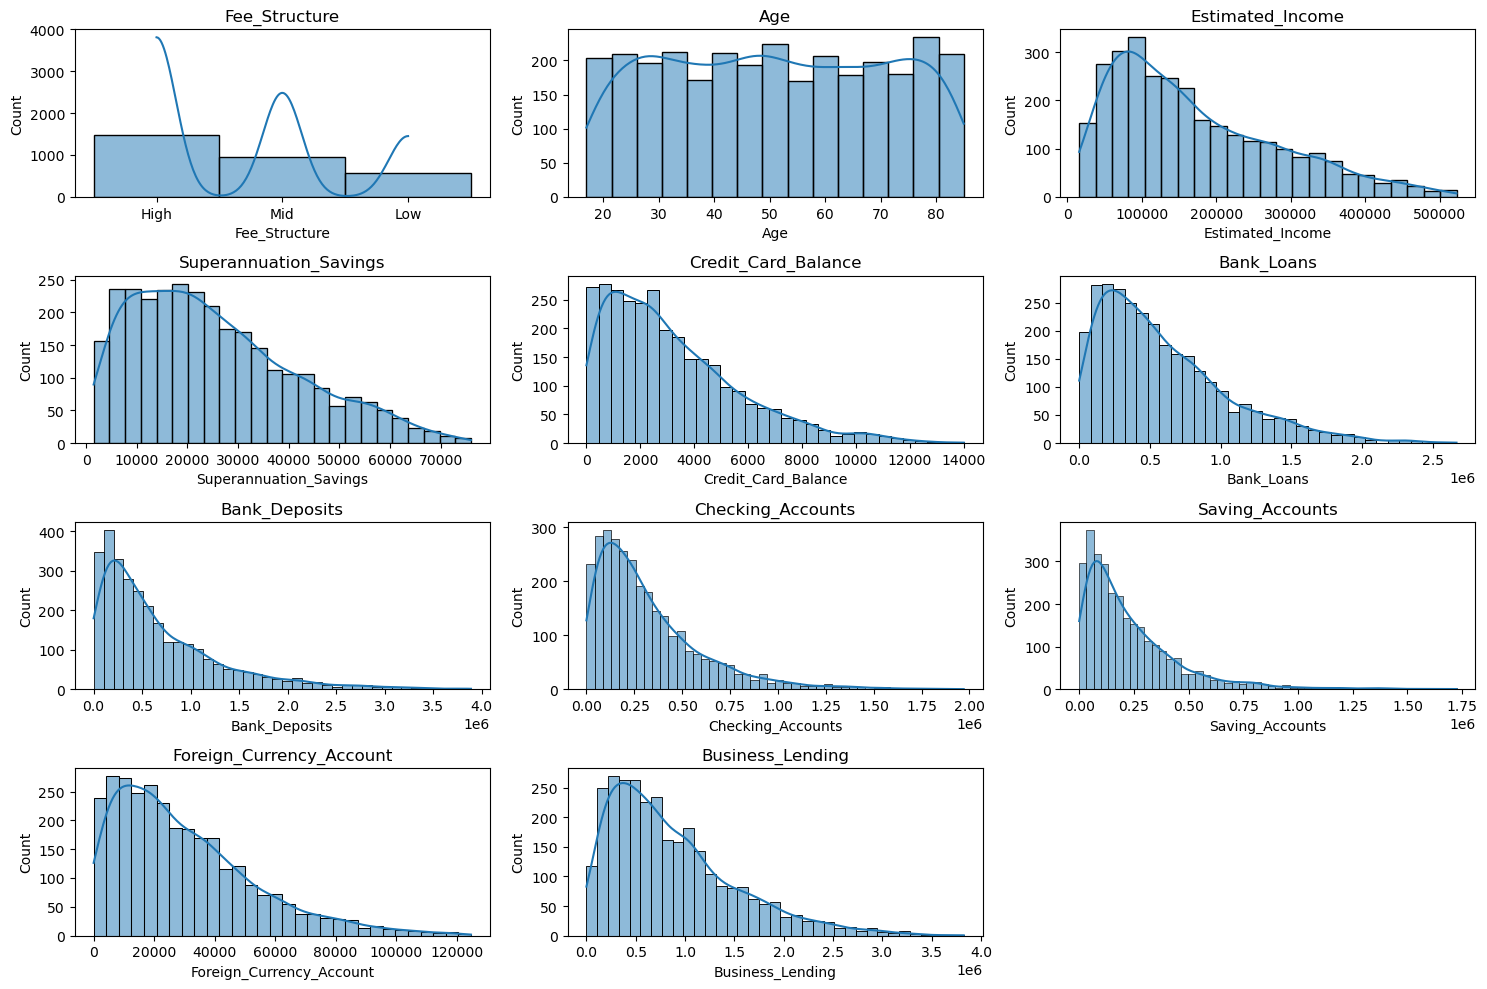

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical analysis and exploration
numerical_cols = ['Fee_Structure','Age', 'Estimated_Income', 'Superannuation_Savings', 'Credit_Card_Balance', 'Bank_Loans', 'Bank_Deposits', 'Checking_Accounts', 'Saving_Accounts', 'Foreign_Currency_Account', 'Business_Lending']

# Univariate analysis and visualization
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()



# Bivariate Analysis

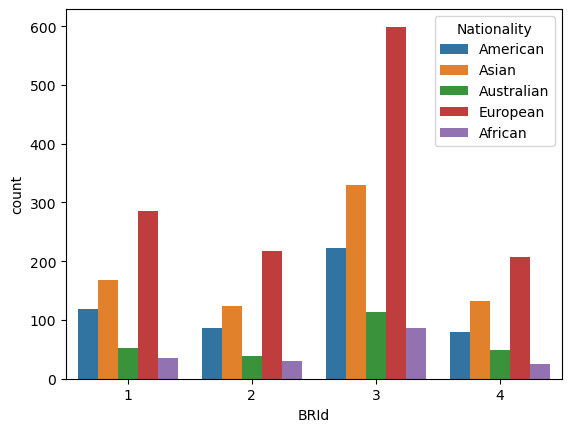

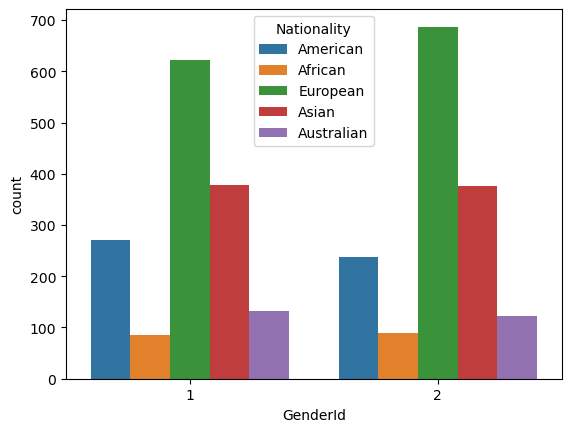

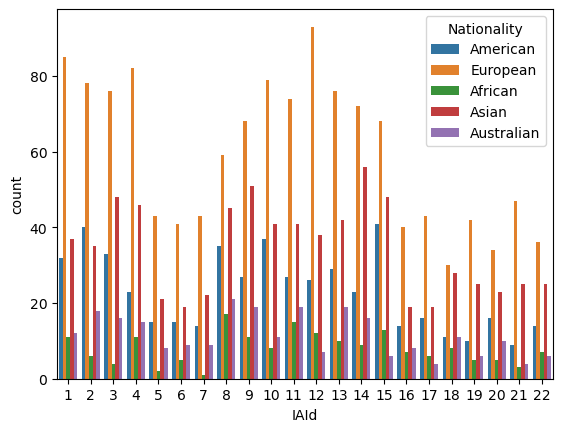

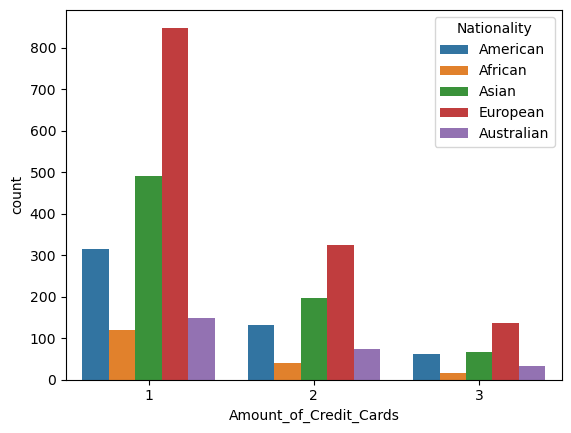

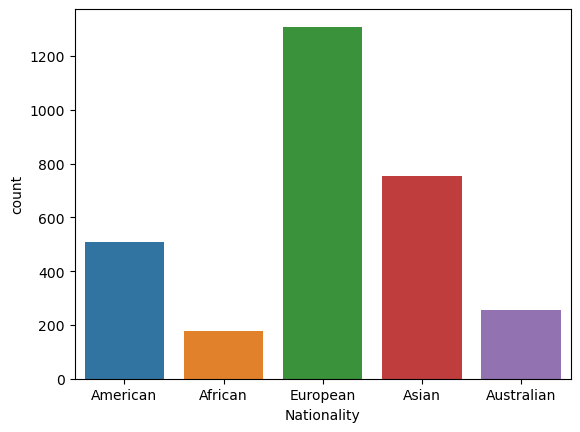

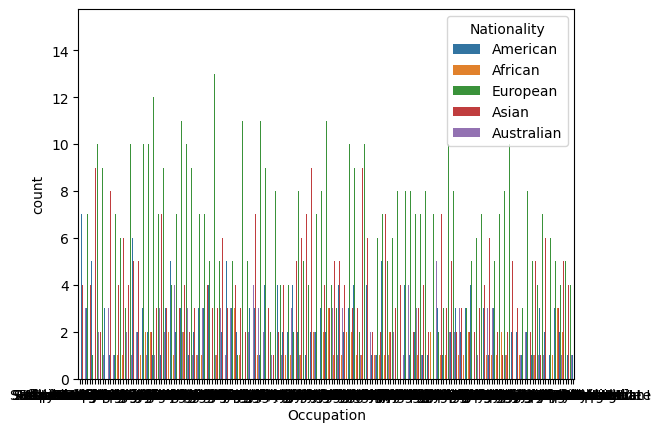

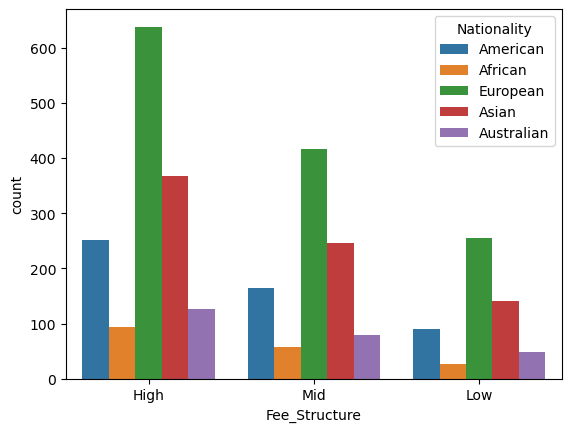

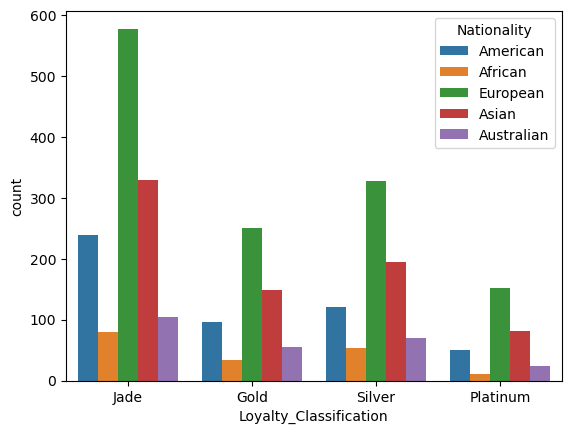

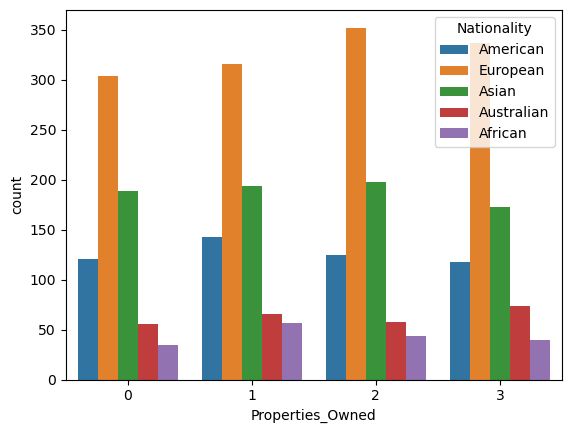

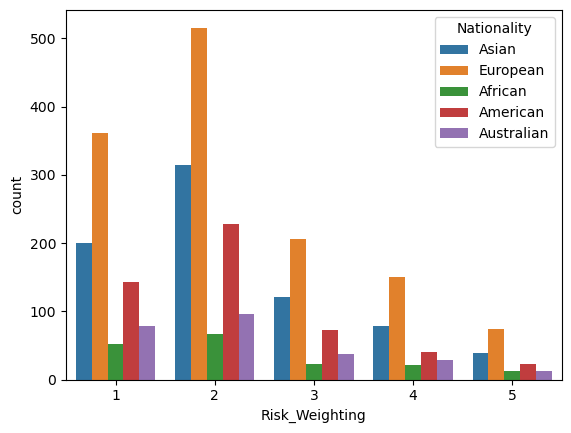

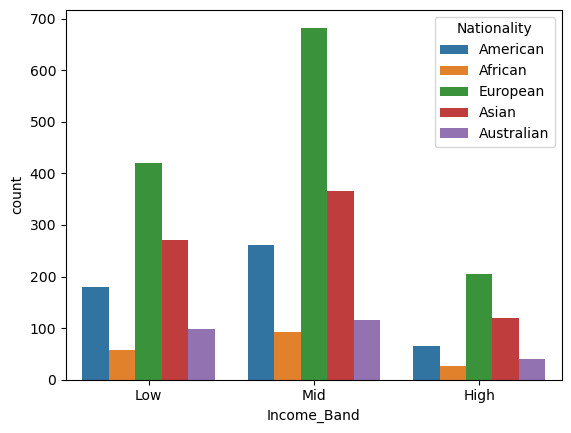

In [18]:
for i, predictor in enumerate(df[["BRId", "GenderId", "IAId", "Amount_of_Credit_Cards", "Nationality", "Occupation", "Fee_Structure", "Loyalty_Classification", "Properties_Owned", "Risk_Weighting", "Income_Band"]].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='Nationality')

# Create a heatmap of the correlation matrix

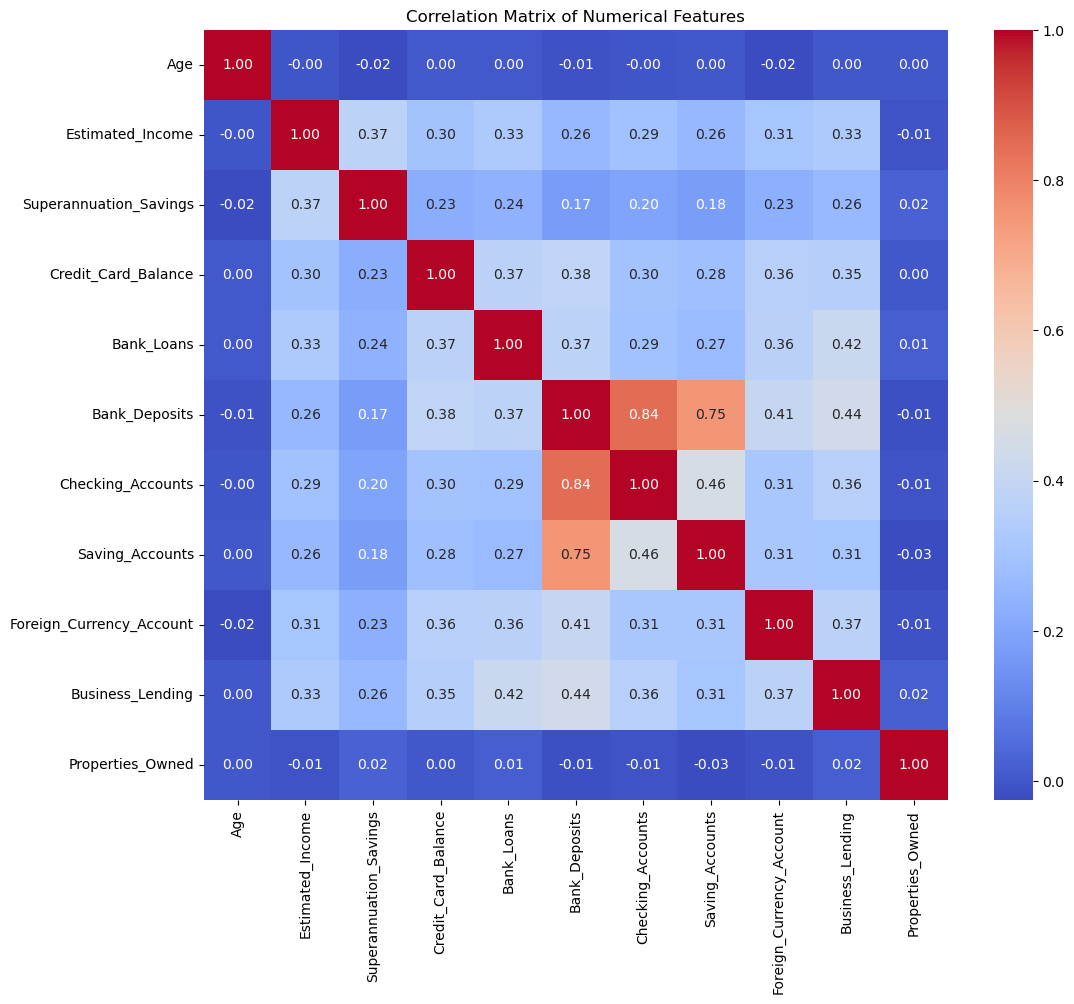

In [16]:

# Select numerical columns for correlation analysis
numerical_cols = ['Age', 'Estimated_Income', 'Superannuation_Savings', 'Credit_Card_Balance',
                  'Bank_Loans', 'Bank_Deposits', 'Checking_Accounts', 'Saving_Accounts',
                  'Foreign_Currency_Account', 'Business_Lending', 'Properties_Owned']

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

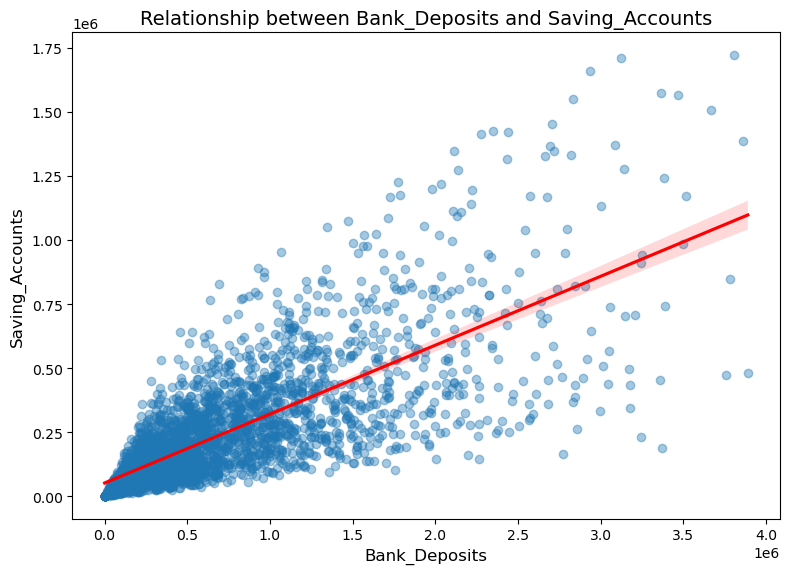

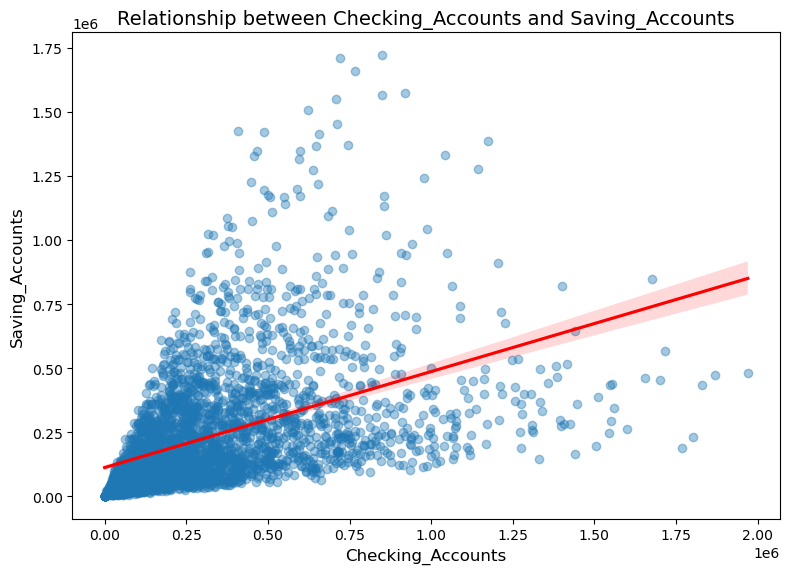

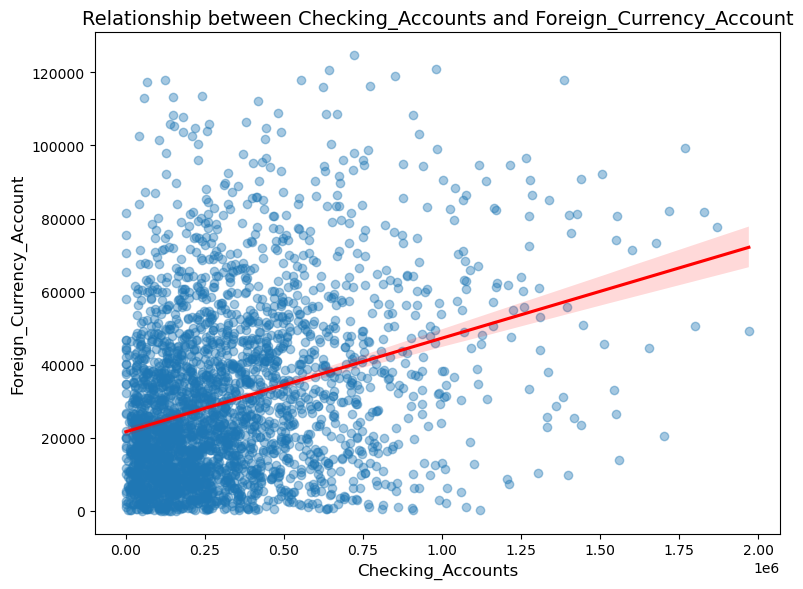

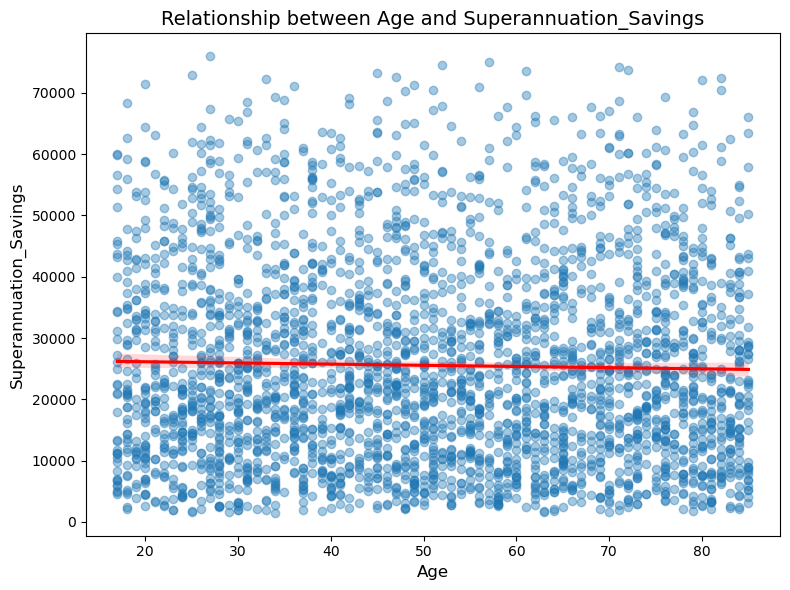

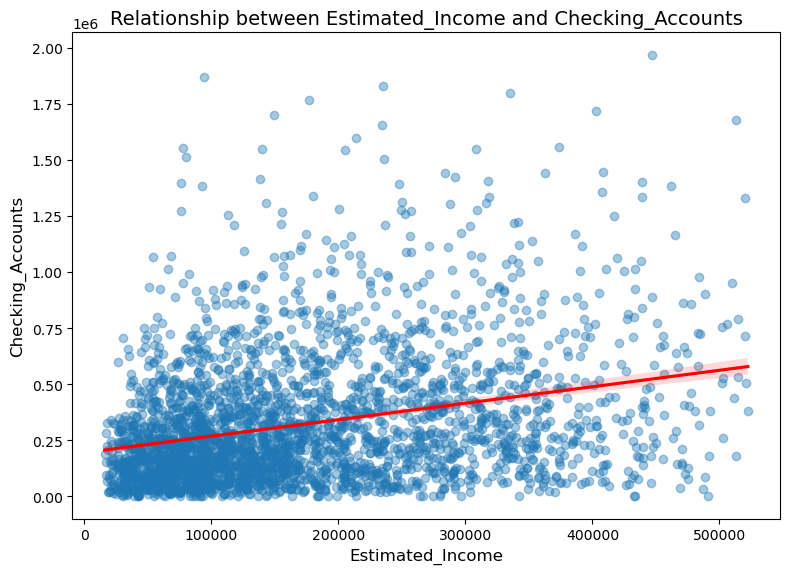

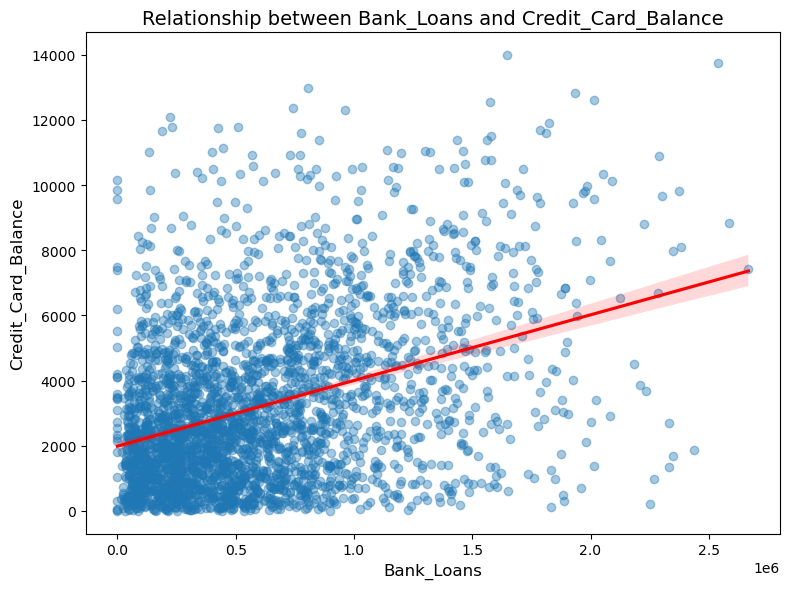

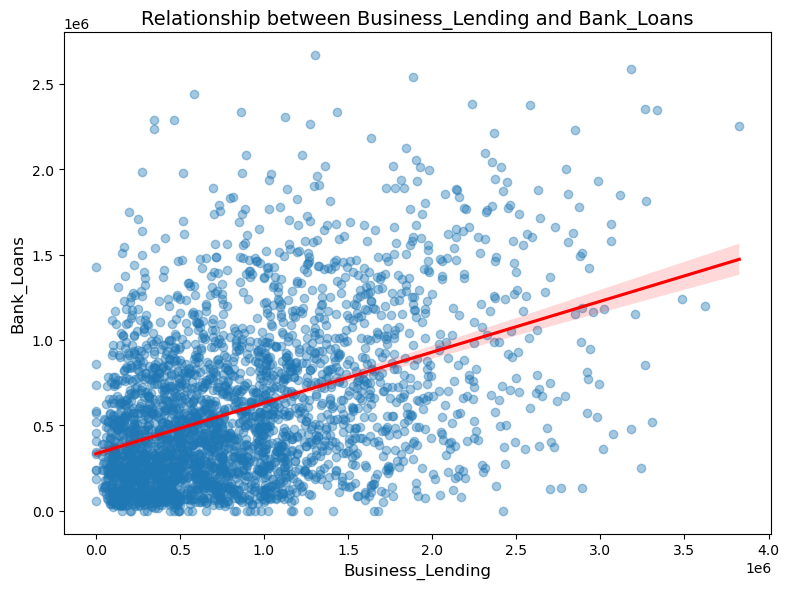

In [17]:
pairs_to_plot = [
    ('Bank_Deposits', 'Saving_Accounts'),
    ('Checking_Accounts', 'Saving_Accounts'),
    ('Checking_Accounts', 'Foreign_Currency_Account'),
    ('Age', 'Superannuation_Savings'),
    ('Estimated_Income', 'Checking_Accounts'),
    ('Bank_Loans', 'Credit_Card_Balance'),
    ('Business_Lending', 'Bank_Loans'),
]


for x_col, y_col in pairs_to_plot:
    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        scatter_kws={'alpha': 0.4},     # semi-transparent points
        line_kws={'color': 'red'}       # best-fit line color
    )
    plt.title(f'Relationship between {x_col} and {y_col}', fontsize=14)
    plt.xlabel(x_col, fontsize=12)
    plt.ylabel(y_col, fontsize=12)
    plt.tight_layout()
    plt.show()

# Insights:




##Deposits and Savings Behavior

The high correlation between Bank Deposits and Saving Accounts suggests that these may either measure overlapping financial behavior (e.g., total funds a customer keeps in the bank) or that people who actively deposit funds also tend to maintain or grow savings balances.


## Income, Age, and Accumulation

Moderate correlations of Age and Estimated Income with various balances (Superannuation, Savings, Checking) reflect a common financial lifecycle trend: higher income earners and older individuals often accumulate more savings, retirement funds, and may carry higher credit card balances or loans.


##Low Correlation with Properties Owned

Property ownership may depend on external factors (location, real estate market conditions, inheritance, etc.) that are not captured by these particular banking variables. Hence, we see weaker correlations here.


##Business vs. Personal Banking


Business Lending’s moderate link to Bank Loans suggests some customers may have both personal and business debts. However, business lending is relatively uncorrelated with other deposit or property-related metrics, indicating it may serve a distinct subset of customers or needs.
